# P01 - Imagen log-mel 128 x 512

Este notebook muestra el cambio central respecto a P00.

En P00 el espectrograma se resumia en `323` features tabulares. En P01 se conserva como una imagen de audio: `128` bandas mel por `512` frames de tiempo. Esa matriz es la entrada natural para una CNN, porque mantiene la forma tiempo-frecuencia del sonido.


## Imports y configuracion


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ModuleNotFoundError:
    display = print

ROOT = Path.cwd()
if ROOT.name == '02_preprocesamiento':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / '02_preprocesamiento' / 'results'
FIG_DIR = RESULTS_DIR / 'figures'
INVESTIGATION = ROOT / 'investigation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(INVESTIGATION))

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 220)
plt.style.use('default')
plt.rcParams.update({
    'figure.figsize': (9, 4.8),
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

from scripts.fat2019.features import read_wav_mono, log_mel_spectrogram, extract_log_mel_stats
from numpy.lib.format import read_magic, _read_array_header


def npz_array_headers(path: Path) -> pd.DataFrame:
    rows = []
    with zipfile.ZipFile(path) as zf:
        for info in zf.infolist():
            if not info.filename.endswith('.npy'):
                continue
            with zf.open(info) as f:
                version = read_magic(f)
                shape, fortran_order, dtype = _read_array_header(f, version)
            rows.append({
                'array': info.filename.replace('.npy', ''),
                'shape': str(shape),
                'dtype': str(dtype),
                'uncompressed_mb': round(info.file_size / 1024**2, 2),
                'compressed_mb': round(info.compress_size / 1024**2, 2),
            })
    return pd.DataFrame(rows)

print(f'FIG_DIR={FIG_DIR.relative_to(ROOT)}')


FIG_DIR=02_preprocesamiento/results/figures


## 1. Que cambia respecto a P00

P00 y P01 parten del mismo audio, pero guardan distinta cantidad de estructura.

- P00 resume el log-mel por banda: media, desvio, maximo y percentil 75. Eso da una fila tabular de `323` features.
- P01 conserva una matriz `128 x 512`: 128 bandas mel y 512 posiciones temporales.

La diferencia importante es el tiempo. En P00 se pierde el orden temporal; en P01 todavia se ve cuando aparece cada patron.


In [2]:
comparison = pd.DataFrame([
    {
        'pipeline': 'P00_logmel_stats_basic',
        'representation': 'tabla',
        'shape_per_audio': '323 features',
        'keeps_time_axis': False,
        'model_family': 'LogisticRegression / modelos tabulares',
    },
    {
        'pipeline': 'P01_logmel_image_512',
        'representation': 'imagen log-mel',
        'shape_per_audio': '128 x 512',
        'keeps_time_axis': True,
        'model_family': 'CNN',
    },
])
display(comparison)
comparison.to_csv(RESULTS_DIR / 'P01_vs_P00_representation_comparison.csv', index=False)


,pipeline,representation,shape_per_audio,keeps_time_axis,model_family
0,P00_logmel_stats_basic,tabla,323 features,False,LogisticRegression / modelos tabulares
1,P01_logmel_image_512,imagen log-mel,128 x 512,True,CNN


## 2. Forma del tensor guardado

La verificacion minima del archivo es comprobar que el dataset de imagenes tiene la forma esperada. No cargamos todo el array pesado: leemos el encabezado interno del `.npz`.


In [3]:
cache_path = DATA_DIR / 'curated_logmel_image_m128_f512.npz'
test_cache_path = DATA_DIR / 'test_logmel_image_m128_f512.npz'

summary = pd.concat([
    npz_array_headers(cache_path).assign(split='curated', cache='curated_logmel_image_m128_f512'),
    npz_array_headers(test_cache_path).assign(split='test', cache='test_logmel_image_m128_f512'),
], ignore_index=True)
display(summary[['split', 'cache', 'array', 'shape', 'dtype', 'compressed_mb']])
summary.to_csv(RESULTS_DIR / 'P01_logmel_image_512_summary.csv', index=False)


,split,cache,array,shape,dtype,compressed_mb
0,curated,curated_logmel_image_m128_f512,x,"(4964, 128, 512)",float16,348.30
1,curated,curated_logmel_image_m128_f512,fnames,"(4964,)",<U12,0.03
2,test,test_logmel_image_m128_f512,x,"(3361, 128, 512)",float16,291.01
3,test,test_logmel_image_m128_f512,fnames,"(3361,)",<U12,0.02


## 3. Ejemplo visual: de waveform a imagen log-mel

Aca se ve por que hablamos de imagen. El eje horizontal es tiempo, el eje vertical son bandas mel, y el color indica energia. Una CNN puede aprender manchas, texturas, repeticiones y cambios locales en esa imagen.


,fname,labels,waveform_samples,duration_seconds,full_logmel_shape,p01_shape_after_crop_or_pad,p00_stats_features
0,0006ae4e.wav,Bark,310456,7.04,"(128, 605)","(128, 512)",323


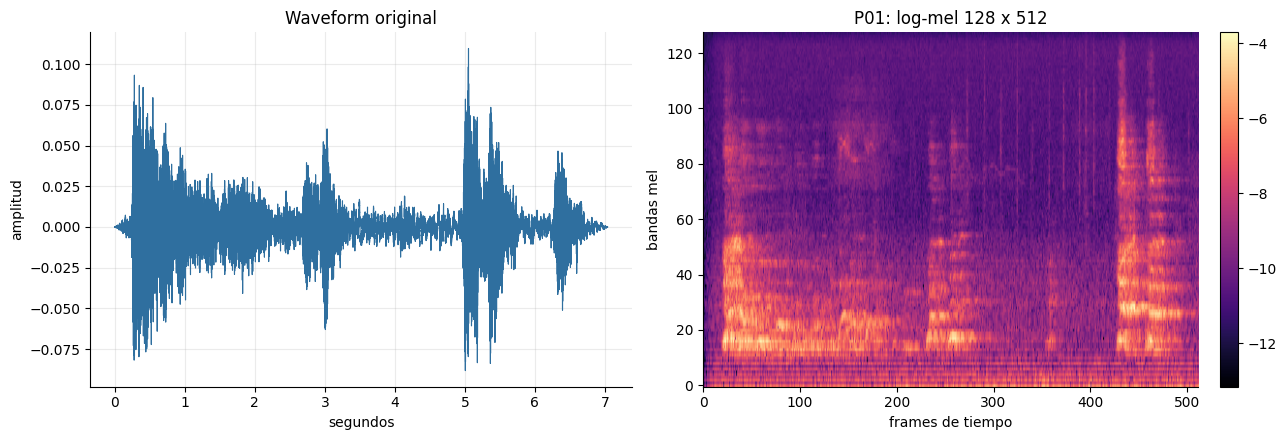

In [4]:
curated = pd.read_csv(DATA_DIR / 'train_curated.csv')
row = curated.iloc[0]
sample_rate, waveform = read_wav_mono(str(DATA_DIR / row['fname']))
logmel_128 = log_mel_spectrogram(
    waveform,
    sample_rate=sample_rate,
    n_fft=1024,
    hop_length=512,
    n_mels=128,
    fmin=20.0,
    fmax=sample_rate / 2,
)

frames = 512
if logmel_128.shape[1] >= frames:
    logmel_512 = logmel_128[:, :frames]
else:
    pad_width = frames - logmel_128.shape[1]
    logmel_512 = np.pad(logmel_128, ((0, 0), (0, pad_width)), mode='constant', constant_values=logmel_128.min())

stats = extract_log_mel_stats(waveform, sample_rate=sample_rate, fmax=sample_rate / 2)

display(pd.DataFrame([{
    'fname': row['fname'],
    'labels': row['labels'],
    'waveform_samples': waveform.size,
    'duration_seconds': round(waveform.size / sample_rate, 3),
    'full_logmel_shape': str(logmel_128.shape),
    'p01_shape_after_crop_or_pad': str(logmel_512.shape),
    'p00_stats_features': stats.shape[0],
}]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(np.arange(waveform.size) / sample_rate, waveform, linewidth=0.8, color='#2f6f9f')
axes[0].set_title('Waveform original')
axes[0].set_xlabel('segundos')
axes[0].set_ylabel('amplitud')
axes[0].grid(True, alpha=0.25)

im = axes[1].imshow(logmel_512, origin='lower', aspect='auto', cmap='magma')
axes[1].set_title('P01: log-mel 128 x 512')
axes[1].set_xlabel('frames de tiempo')
axes[1].set_ylabel('bandas mel')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIG_DIR / 'P01_waveform_to_logmel_image.png', dpi=140, bbox_inches='tight')
plt.show()


## 4. Que pierde P00 y conserva P01

Para que se vea la diferencia, abajo se compara el resumen P00 con la imagen P01. P00 guarda curvas agregadas por banda; P01 conserva la ubicacion temporal de los eventos.


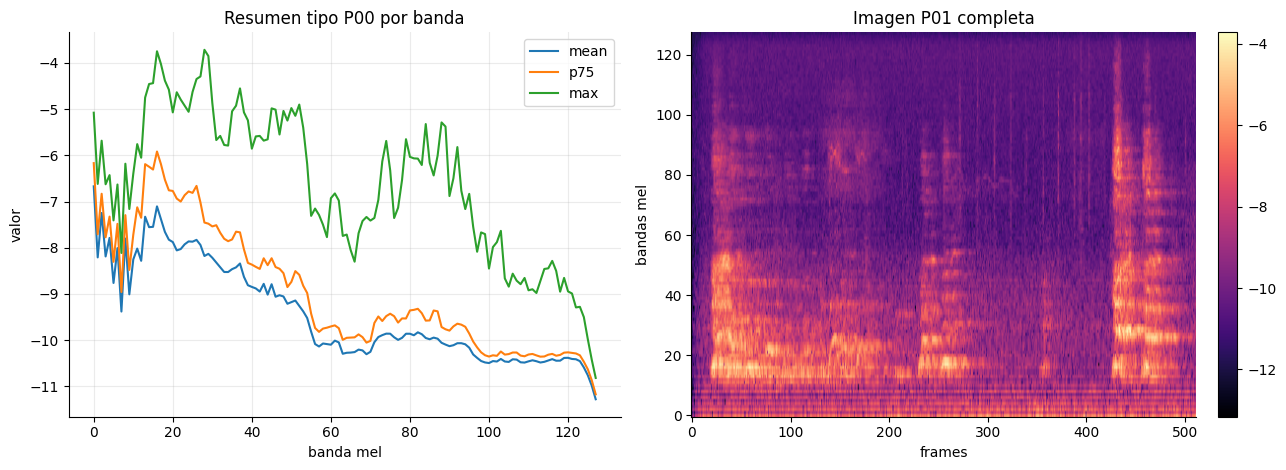

In [5]:
mel_band = np.arange(logmel_512.shape[0])
p00_like_summary = pd.DataFrame({
    'mel_band': mel_band,
    'mean': logmel_512.mean(axis=1),
    'p75': np.percentile(logmel_512, 75, axis=1),
    'max': logmel_512.max(axis=1),
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(p00_like_summary['mel_band'], p00_like_summary['mean'], label='mean')
axes[0].plot(p00_like_summary['mel_band'], p00_like_summary['p75'], label='p75')
axes[0].plot(p00_like_summary['mel_band'], p00_like_summary['max'], label='max')
axes[0].set_title('Resumen tipo P00 por banda')
axes[0].set_xlabel('banda mel')
axes[0].set_ylabel('valor')
axes[0].grid(True, alpha=0.25)
axes[0].legend()

im = axes[1].imshow(logmel_512, origin='lower', aspect='auto', cmap='magma')
axes[1].set_title('Imagen P01 completa')
axes[1].set_xlabel('frames')
axes[1].set_ylabel('bandas mel')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIG_DIR / 'P01_p00_summary_vs_image.png', dpi=140, bbox_inches='tight')
plt.show()


## 5. Evidencia de impacto

La comparacion completa de variantes queda en `10_p00vsp01vsp02.ipynb`. En este notebook solo se deja la evidencia minima del salto que justifica P01: pasar de stats tabulares a imagen log-mel permitio usar CNNs y subir fuerte el private LB.


,step,representation,private_lb,reading,delta_vs_previous
0,P00 + sklearn C=0.01,stats log-mel,0.37607,baseline tabular regularizado,NaN
1,P01 + CNN log-mel,imagen log-mel 128x512,0.52257,conserva estructura tiempo-frecuencia,0.1465


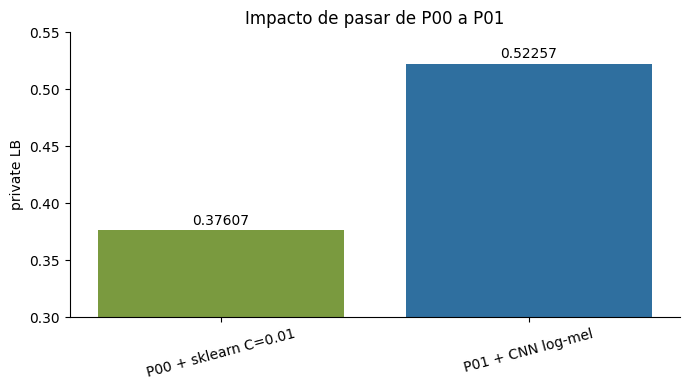

In [6]:
evidence = pd.DataFrame([
    {'step': 'P00 + sklearn C=0.01', 'representation': 'stats log-mel', 'private_lb': 0.37607, 'reading': 'baseline tabular regularizado'},
    {'step': 'P01 + CNN log-mel', 'representation': 'imagen log-mel 128x512', 'private_lb': 0.52257, 'reading': 'conserva estructura tiempo-frecuencia'},
])
evidence['delta_vs_previous'] = evidence['private_lb'].diff()
display(evidence)

evidence.to_csv(RESULTS_DIR / 'P01_impact_evidence.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(evidence['step'], evidence['private_lb'], color=['#7a9a3f', '#2f6f9f'])
ax.set_title('Impacto de pasar de P00 a P01')
ax.set_ylabel('private LB')
ax.set_ylim(0.30, 0.55)
ax.tick_params(axis='x', rotation=15)
for idx, value in enumerate(evidence['private_lb']):
    ax.text(idx, value + 0.005, f'{value:.5f}', ha='center')
fig.tight_layout()
fig.savefig(FIG_DIR / 'P01_impact_private_lb.png', dpi=140, bbox_inches='tight')
plt.show()


## Decision

- Promover `128 x 512` como representacion base para CNN.
- Mantener P00 como baseline tabular, pero no esperar que gane cuando el orden temporal importa.
- Si se cambia `frames`, `n_mels` o normalizacion, debe quedar como una variante nueva y compararse contra P01.
